`markdown
# 통합 챗봇(입시 + 비자) 라우팅 구현 계획

## Proposed Changes
- 방금 보여주신 run_agent는 펜실베이니아 대학 입시 정보(RDB)를 조회하는 에이전트 방식이고, 우리가 만든 비자 챗봇은 파인튜닝된 페르소나 방식입니다.

- 이 두 가지를 하나의 챗봇처럼 매끄럽게 연결하려면, 질문이 들어왔을 때 "이게 입시 질문인지, 비자 질문인지"를 먼저 판단하는 '라우터(Router)' 기능을 추가하면 됩니다.

📋 통합 챗봇 구현 계획
- 기존의 run_agent 코드를 유지하면서, 파인튜닝된 모델(f1-visa-expert)을 함께 사용하는 통합 구조를 제안합니다.

### 1. 모델 개별 정의
- `admissions_agent`: 기존의 RDB 기반 LangGraph 에이전트 (Gemma 3 12B 사용)
- `visa_llm`: 우리가 파인튜닝한 비자 전용 모델 (ChatOllama `f1-visa-expert`)

### 2. 시맨틱 라우터(Semantic Router) 추가
- 질문의 의도를 판단하는 `classify_intent` 함수 구현
- 질문 예시:
    - "UPenn 입시 마감일이 언제야?" -> `ADMISSIONS`
    - "비자 면접에서 재학 증명서가 왜 필요해?" -> `VISA`

### 3. 통합 실행 함수 (`run_integrated_chatbot`) 구현
- 라우터의 결과에 따라 기존 `run_agent`를 실행하거나 새 `visa_llm`을 실행

## Open Questions

- **라우팅 방식:** LLM을 써서 의도를 분류할까요, 아니면 사용자가 UI(예: '비자 인터뷰 모드')로 직접 선택하게 할까요? (LLM 자동 분류를 추천합니다.)
- **비역질문 처리:** 만약 입시와 비자를 동시에 묻는다면 어떻게 처리할까요? (가장 비중이 높은 쪽으로 라우팅하거나 에이전트의 도구로 비자 검색을 추가하는 방법이 있습니다.)

In [1]:
pip install -U langchain-ollama

Note: you may need to restart the kernel to use updated packages.


In [2]:
# !pip install langchain langchain-community sqlalchemy pymysql
# !pip install langchain_ollama
# !pip install langchain langchain-community langgraph langchain-ollama sqlalchemy pymysql python-dotenv
# !pip install -U langchain langchain-core langchain-community

In [38]:
from dotenv import load_dotenv
import os

# os.chdir("/workspace/3차프로젝트")
# 현재 경로 기준으로 .env 불러오기 (vscode)
# load_dotenv(dotenv_path="C:/skn24/수업자료/08_large_language_model/05_langgraph/3차프로젝트/env")

# runpod
os.chdir("/workspace/3차프로젝트")
load_dotenv(dotenv_path="/workspace/3차프로젝트/env")

print(os.getenv("DB_USER"), os.getenv("DB_PASSWORD"))

myuser 123


In [39]:
from langchain_community.chat_models import ChatOllama
#############################################################################
def get_router_llm():
    return ChatOllama(
        model="llama3:8b",   # 빠르고 충분
        temperature=0
    )

llm = ChatOllama(
    model="ebdm/gemma3-enhanced:12b",  # 이미 쓰는거
    temperature=0
)

#############################################################################
def get_service2_llm():
    return ChatOllama(
        model="llama3:8b",   # 대화용
        temperature=0.3
    )

# graph.py 또는 router_node 파일
visa_llm = get_service2_llm()
#############################################################################
def get_router_llm():
    return ChatOllama(
        model="llama3:8b",   # 빠르고 충분
        temperature=0
    )
router_llm = get_router_llm()
# def router_node(state):
    question = state["messages"][-1].content

    prompt = f"""
    당신은 질문의 목적이 '정보 조회'인지 '인터뷰 연습'인지 판별하는 전문가입니다.

    [분류 규칙]
    1. INTERVIEW (Service 2): 
       - '인터뷰', '면접' 단어가 포함된 경우
       - '서류 준비', '어떻게 답변해', '연습하자' 등 준비 과정 관련
       - 실제 면접 시뮬레이션이 필요한 상황
    
    2. ADMISSIONS (Service 1): 
       - 대학의 객관적 데이터 (학비, 위치, 랭킹, 입학 마감일)
       - 데이터베이스 조회가 필요한 사실 정보

    ※ 중요: '인터뷰 서류'는 인터뷰 준비 과정이므로 무조건 INTERVIEW로 분류하세요.

    질문: {question}
    분류: """

    response = router_llm.invoke(prompt)
    res_text = response.content.strip().upper()
    
    # "INTERVIEW" 문자열이 포함되어 있으면 service2로 결정
    route = "service2" if "INTERVIEW" in res_text else "service1"
    
    print(f"--- [ROUTER] {question} -> {route} ---") # 분류 결과 확인용 로그
    return {"route": route}
############################################################################
# def router_node(state):
#     question = state["messages"][-1].content

#     prompt = f"""
# 사용자의 질문을 읽고 아래 두 가지 중 하나로 분류하세요.

# --------------------------------
# [카테고리]

# 1. INTERVIEW
# - 비자 인터뷰 / 면접 관련 모든 질문
# - 예상 질문, 답변, 준비, 연습
# - 인터뷰 팁, 합격 전략
# - mock interview, roleplay
# - 긴장, 떨어질까, 어떻게 답해

# 2. ADMISSIONS
# - 그 외 모든 질문
# - 대학 정보 (주소, 학비, 마감일)
# - 입시 요구사항 (SAT, GPA, 서류 등)
# - FAQ, 일반 질문
# - 비자 발급 절차, 미국대학교 입학 및 입시 서류 관련 질문도 포함

# --------------------------------
# [동의어 및 분류 규칙]

# ▶ INTERVIEW (최우선)
# - 인터뷰, 면접, interview
# - 질문, 예상 질문, question
# - 답변, answer, response
# - 준비, 연습, practice, mock, roleplay
# - 팁, 전략, 요령
# - "뭐 물어봐", "어떻게 답해", "긴장돼", "떨어질까"

# → 하나라도 포함되면 무조건 INTERVIEW

# ▶ ADMISSIONS
# - 위 INTERVIEW가 아닌 모든 경우

# --------------------------------
# [중요 규칙]

# 1. 인터뷰 관련 단어가 하나라도 있으면 → 무조건 INTERVIEW
# 2. 나머지는 전부 → ADMISSIONS
# 3. 절대 다른 카테고리 만들지 말 것

# --------------------------------
# [출력 규칙]

# 반드시 아래 중 하나만 출력:
# - INTERVIEW
# - ADMISSIONS

# 절대 설명하지 말고 단어 하나만 출력하세요.

# --------------------------------
# [예시]

# 질문: "비자 인터뷰 뭐 물어봐?"
# 답변: INTERVIEW

# 질문: "인터뷰 준비 어떻게 해?"
# 답변: INTERVIEW

# 질문: "뉴욕대학교 학비 얼마야?"
# 답변: ADMISSIONS

# 질문: "SAT 점수 기준 뭐야?"
# 답변: ADMISSIONS

# 질문: "DS-160 작성 방법"
# 답변: ADMISSIONS

# 질문: "비자 발급 절차 알려줘"
# 답변: ADMISSIONS

# --------------------------------

# 질문: {question}
# """

    
#     response = router_llm.invoke(prompt)
#     text = response.content.strip().upper()
    
#     # route 결정 (생략 가능하지만 가독성을 위해)
#     route = "service1" if text == "ADMISSIONS" else "service2"
    
#     return {
#         "route": route
#     }

IndentationError: unexpected indent (1794869963.py, line 31)

In [120]:
def router_node(state: MultiAgentState):
    # 메시지 추출 (안전하게)
    last_msg = state["messages"][-1]
    question = last_msg.content if hasattr(last_msg, 'content') else last_msg[1]

    prompt = f"""
    당신은 질문 분류기입니다. 아래 규칙에 따라 오직 한 단어 'ADMISSIONS' 또는 'INTERVIEW'만 출력하세요.

    - '학비', '대학 정보', '입학', 'GPA', 'SAT' 관련 질문 -> ADMISSIONS
    - '비자 인터뷰 연습', '모의 면접', '나랑 연습하자' 관련 질문 -> INTERVIEW

    질문: {question}
    분류 (단어 하나만): """

    response = router_llm.invoke(prompt)
    decision = response.content.strip().upper()
    
    # 확실하게 키워드 매칭
    if "INTERVIEW" in decision:
        route = "service2"
    else:
        route = "service1"

    print(f"--- [ROUTER DEBUG] 질문: {question} | LLM 답변: {decision} | 최종 경로: {route} ---")
    
    # ⚠️ 중요: state 전체를 반환하면서 route를 업데이트해야 합니다.
    return {**state, "route": route}

In [121]:
# graph (service2) 
def visa_node(state):
    # 전역 변수 visa_llm을 사용함을 명시 (선택사항이지만 안전함)
    global visa_llm
    
    question = state["messages"][-1].content
    
    # 여기서 visa_llm이 정의되어 있지 않으면 위 NameError가 납니다.
    response = visa_llm.invoke(question) 
    
    return {
        "messages": [("assistant", response.content)]
    }

def build_service2_graph():
    builder = StateGraph(MessagesState)

    builder.add_node("visa_node", visa_node)

    builder.add_edge(START, "visa_node")
    builder.add_edge("visa_node", END)

    return builder.compile()

# 메인 그래프 (Router + Subgraph 연결)


In [122]:
# !pip install librosa
# !pip install sounddevice
# !pip install pyaudio
# !pip install pandas
# !pip install datasets
# !pip install openai
# !pip install langchain_huggingface
# !pip install langchain_chroma
# !pip install pdf2image
# !pip install pytesseract
!pip install sentence-transformers

In [123]:

from dotenv import load_dotenv
import os
# 현재 경로 기준으로 .env 불러오기
load_dotenv(dotenv_path="/workspace/3차프로젝트/env")

# print(os.getenv("DB_USER"), os.getenv("DB_PASSWORD"))

True

In [149]:
from langgraph.graph import StateGraph, START, END, MessagesState
from graph import build_state_graph
from graph import graph
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from prompts import generate_query_system_prompt
from service_2_run import run_service_2_visa
from typing import Annotated, TypedDict  
from langgraph.graph.message import add_messages

class MultiAgentState(TypedDict):
    messages: Annotated[list, add_messages]
    route: str
    user_pdf_path: str  # 사용자가 업로드한 PDF 경로를 저장할 곳

def service1_node(state):
    """service1_graph를 단일 노드처럼 실행"""
    return service1_graph.invoke(state)  # 내부 메시지 그대로 전달

# def service2_node(state):
#     # 여기서 visa_llm을 사용하는 visa_node 로직을 넣거나 
#     # 별도의 서브그래프를 invoke 합니다.
#     question = state["messages"][-1].content
#     response = visa_llm.invoke(question) # <- 여기서 visa_llm 사용!
#     return {"messages": [("assistant", response.content)]}
# multiagent.ipynb 내 서비스 2 정의 부분

    
def service2_node(state: MultiAgentState):
    """
    state에 저장된 PDF 경로를 사용하여 인터뷰 엔진을 실행합니다.
    """
    # 1. State에서 경로 추출 (없을 경우를 대비한 기본값 설정 가능)
    pdf_path = state.get("user_pdf_path", "data_user_data/default.pdf")
    essay_path = state.get("essay_pdf_path", None)

    print(f"\n[Service 2] {pdf_path} 파일을 기반으로 인터뷰를 생성합니다.")

    try:
        # 2. 기존 run 함수에 동적 경로 전달
        run_service_2_visa(
            user_pdf_path=pdf_path, 
            essay_pdf_path=essay_path,
            n_questions=2,
            record_duration=8
        )
        
        return {
            "messages": [("assistant", "인터뷰와 AI 평가가 완료되었습니다. 확인해 보세요!")]
        }
        
    except Exception as e:
        return {
            "messages": [("assistant", f"PDF 분석 중 오류가 발생했습니다: {str(e)}")]
        }
        
# # 2️⃣ 서브그래프 빌드
# service1_graph = build_state_graph()
# service2_graph = build_service2_graph()

# # 3️⃣ 메인 그래프
# builder = StateGraph(MessagesState)

# builder.add_node("router", router_node)
# builder.add_node("service1", service1_node)  # 래퍼 함수 사용
# builder.add_node("service2", service2_node)

# # 시작 → 라우터
# builder.add_edge(START, "router")

# # 라우터 분기
# from nodes.conditions import route_decision # 새로 만든 함수 임포트

# builder.add_conditional_edges(
#     "router",
#     route_decision, # 람다 함수 대신 이걸 쓰면 더 깔끔합니다.
#     {
#         "service1": "service1",
#         "service2": "service2"
#     }
# )

# # 각 서비스 → 종료
# builder.add_edge("service1", END)
# builder.add_edge("service2", END)

# # 컴파일
# multi_agent_graph = builder.compile()

# # 4️⃣ 테스트
# # if __name__ == "__main__":
# #     initial_input = {
# #         "messages": [("user", "내 서류 바탕으로 비자 인터뷰 연습하고 싶어")],
# #         "user_pdf_path": "workspace/3차프로젝트/f-1_yuji.pdf",  # 실제 파일 저장 경로
# #         "essay_pdf_path": None
# #     }
    
# #     result = multi_agent_graph.invoke(initial_input)

builder = StateGraph(MultiAgentState)

builder.add_node("router", router_node)
builder.add_node("service1", service1_node)
builder.add_node("service2", service2_node)

builder.add_edge(START, "router")

# 조건부 엣지 설정
builder.add_conditional_edges(
    "router",
    route_decision,
    {
        "service1": "service1",
        "service2": "service2"
    }
)

builder.add_edge("service1", END)
builder.add_edge("service2", END)

multi_agent_graph = builder.compile()

In [141]:
# from langgraph.graph import StateGraph, START, END, MessagesState
# from graph import build_state_graph
# from graph import graph

# # 서브그래프 생성
# service1_graph = build_state_graph()
# service2_graph = build_service2_graph()

# # 메인 그래프
# builder = StateGraph(MessagesState)
# service1_app = service1_graph
# service2_app = service2_graph

# # 노드 추가
# builder.add_node("router", router_node)

# builder.add_node("service1", service1_app)
# builder.add_node("service2", service2_app)

# # 시작
# builder.add_edge(START, "router")

# # 라우팅 분기
# builder.add_conditional_edges(
#     "router",
#     lambda state: state["route"],
#     {
#         "service1": "service1",  # ADMISSIONS → SQL
#         "service2": "service2"   # INTERVIEW → QA
#     }
# )

# # 종료
# builder.add_edge("service1", END)
# builder.add_edge("service2", END)

# graph = builder.compile()

### 최종 실행 함수

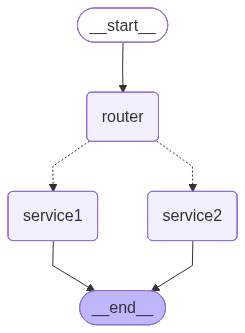

In [142]:
from IPython.display import Image, display
display(Image(multi_agent_graph.get_graph().draw_mermaid_png()))

In [143]:
def run_multi_agent_stream(question: str) -> str:
    result = ""

    for step in graph.stream(
        {"messages": [{"role": "user", "content": question}]},
        stream_mode="values"
    ):
        msg = step["messages"][-1]

        if msg.content:   # ✅ type 체크 제거
            result = msg.content

    return result

In [144]:
# 에러가 발생하는 줄을 아래와 같이 수정하세요

result = run_multi_agent_stream("펜실베니아에 필요한 서류가 뭐가 있어?")
print(result)

펜실베니아 대학교 지원에 필요한 서류는 다음과 같습니다.

*   **지원서:** 온라인으로 작성 및 제출해야 합니다.
*   **고등학교 졸업 증명서:** 정식 졸업 증명서를 제출해야 합니다.
*   **성적 증명서:** 고등학교 성적을 증명하는 공식 성적 증명서를 제출해야 합니다.
*   **표준화 시험 점수:** SAT 또는 ACT 점수를 제출해야 합니다. (대학 정책에 따라 달라질 수 있으니 확인 필요합니다.)
*   **추천서:** 보통 2~3명의 선생님으로부터 추천서를 받아야 합니다.
*   **에세이:** 지원서에 포함된 에세이를 작성해야 합니다.
*   **지원비:** 지원 수수료를 지불해야 합니다. (수수료 면제 대상에 해당되는 경우 면제 가능)

자세한 내용은 펜실베니아 대학교 입학처 홈페이지에서 확인하거나, 입학처에 직접 문의하시는 것을 추천합니다.


In [145]:
from langchain_core.messages import HumanMessage

# stream 말고 invoke로 전체 흐름 확인
response = graph.invoke({"messages": [HumanMessage(content="인터뷰")]})

# 어떤 에이전트들이 대화에 참여했는지 확인
for msg in response['messages']:
    print(f"[{type(msg).__name__}]: {msg.content[:50]}...")

[HumanMessage]: 인터뷰...
[AIMessage]: 사용 가능한 테이블: admission_info, faq_info, requirement_...
[AIMessage]: 

```sql
SELECT
  si.school_name,
  ri.requirement...
[AIMessage]: ...
[AIMessage]: 인터뷰에 대한 정보는 제공되지 않습니다....


In [146]:
def run_multi_agent_stream(question: str, pdf_path: str = None, essay_path: str = None) -> str:
    """
    메인 그래프(multi_agent_graph)를 실행하고 최종 답변을 스트리밍 방식으로 추출합니다.
    """
    # 1. 초기 입력 설정 (메시지 + PDF 경로)
    # MessagesState 구조에 맞춰 입력 구성
    inputs = {
        "messages": [("user", question)],
        "user_pdf_path": pdf_path,
        "essay_pdf_path": essay_path
    }
    
    final_answer = ""

    # 2. multi_agent_graph 실행 (updates 모드)
    for step in multi_agent_graph.stream(inputs, stream_mode="updates"):
        for node_name, content in step.items():
            # 디버깅용: 현재 실행 중인 노드 확인
            print(f"--- [Node: {node_name}] 실행 중 ---")
            
            # 노드 결과물에서 메시지 추출
            if "messages" in content:
                last_msg = content["messages"][-1]
                
                # ✅ 튜플/객체 여부에 따른 안전한 텍스트 추출 (AttributeError 방지)
                if hasattr(last_msg, 'content'):
                    # AIMessage 객체인 경우
                    final_answer = last_msg.content
                elif isinstance(last_msg, (tuple, list)):
                    # ('assistant', '내용') 튜플인 경우
                    final_answer = last_msg[1]
                else:
                    # 그 외 문자열인 경우
                    final_answer = str(last_msg)

    return final_answer

In [147]:
# 실제 실행 시나리오 테스트
if __name__ == "__main__":
    # 테스트 1: 학비 질문 (Service 1로 가야 함)
    print("\n[테스트 1: 학비 질문]")
    ans1 = run_multi_agent_stream("뉴욕대학교 학비 알려줘")
    print(f"결과: {ans1}")

    # 테스트 2: 인터뷰 연습 (Service 2로 가야 함)
    print("\n[테스트 2: 인터뷰 연습]")
    ans2 = run_multi_agent_stream(
        "내 서류 바탕으로 비자 인터뷰 연습하고 싶어", 
        pdf_path="workspace/3차프로젝트/f-1_yuji.pdf"
    )
    print(f"결과: {ans2}")


[테스트 1: 학비 질문]
--- [ROUTER DEBUG] 결정: service1 (LLM 답변: ADMISSIONS) ---
--- [Node: router] 실행 중 ---

[Service 2] None 파일을 기반으로 인터뷰를 생성합니다.
[PDF] Processing user_data: None
--- [Node: service2] 실행 중 ---
결과: PDF 분석 중 오류가 발생했습니다: File path None is not a valid file or url

[테스트 2: 인터뷰 연습]
--- [ROUTER DEBUG] 결정: service2 (LLM 답변: INTERVIEW) ---
--- [Node: router] 실행 중 ---

[Service 2] workspace/3차프로젝트/f-1_yuji.pdf 파일을 기반으로 인터뷰를 생성합니다.
[PDF] Processing user_data: workspace/3차프로젝트/f-1_yuji.pdf
--- [Node: service2] 실행 중 ---
결과: PDF 분석 중 오류가 발생했습니다: File path workspace/3차프로젝트/f-1_yuji.pdf is not a valid file or url


In [148]:
run_multi_agent_stream("비자 인터뷰 연습 시작할래", pdf_path="workspace/3차프로젝트/f-1_yuji.pdf")

--- [ROUTER DEBUG] 결정: service2 (LLM 답변: INTERVIEW) ---
--- [Node: router] 실행 중 ---

[Service 2] workspace/3차프로젝트/f-1_yuji.pdf 파일을 기반으로 인터뷰를 생성합니다.
[PDF] Processing user_data: workspace/3차프로젝트/f-1_yuji.pdf
--- [Node: service2] 실행 중 ---


'PDF 분석 중 오류가 발생했습니다: File path workspace/3차프로젝트/f-1_yuji.pdf is not a valid file or url'